## Question 1: Handwritten Character Classification using Transfer Learning

You are provided with the **EMNIST Dataset** (Extended MNIST), which contains handwritten characters. We will use the **"letters"** split which contains 26 letter classes (A-Z).

Your objective is to **fine-tune a pretrained EfficientNetV2-Small** model to classify handwritten letters.

Your work will be evaluated based on the completion of the following tasks:

# Part 1: Load and Prepare Data

**Tasks:**

- Complete the transforms by adding:
  - Resize images to 28x28
  - Convert to Tensor
  - Normalize using ImageNet mean and std
- Create DataLoaders for training and testing
- Display some sample images

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import EMNIST
from torch.utils.data import DataLoader

# Define transforms - COMPLETE THE MISSING PARTS
transform = transforms.Compose([
    # DONE: Resize to 28x28
    transforms.Grayscale(3),  # Convert grayscale to RGB (Don't Touch!!)
    # DONE: Convert to Tensor
    transforms.ToTensor(),
    # DONE: Normalize with ImageNet mean=[0.485, 0.456, 0.406] and std=[0.229, 0.224, 0.225]
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load EMNIST letters dataset (given)
train_dataset = EMNIST(root='./data', split='letters', train=True, download=True, transform=transform)
test_dataset = EMNIST(root='./data', split='letters', train=False, download=True, transform=transform)

# Note: EMNIST letters has labels 1-26 (A-Z), so we have 26 classes
num_classes = 26

print(f"Training samples: {len(train_dataset)}")
print(f"Testing samples: {len(test_dataset)}")
print(f"Number of classes: {num_classes}")

100%|██████████| 562M/562M [00:03<00:00, 170MB/s]


Training samples: 124800
Testing samples: 20800
Number of classes: 26


In [2]:
# Letter mapping (labels are 1-26 for A-Z) 
letters = 'ABCDEFGHIJKLMNOPQRSTUVWXYZ'

# Create DataLoaders and display samples
# Write your code here

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle=True) # shuffling while training helps improve performance.
test_loader = DataLoader(test_dataset, batch_size = batch_size)

In [3]:
next(iter(train_loader))[1].unique() 
# displaying labels of first batch of images 

tensor([ 1,  2,  3,  6,  7,  8,  9, 10, 11, 12, 13, 16, 17, 19, 21, 22, 24, 25,
        26])

> **As mentioned in above cell(s), letters are labelled from 1-26, not 0-25, which is standard convention for models. Hence, we will need to relabel them.**
> 
> **`train_loader` returns a tuple of 2 items in the format `(images, labels)`. Selected the labels and displayed the unique elements in them.**

In [4]:
# checking size/shape of images
next(iter(train_loader))[0][0].shape

torch.Size([3, 28, 28])

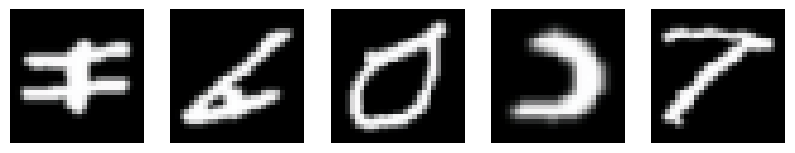

In [5]:
# Now displaying some sample images.

# denormalize fn to remove imagenet normalization
import numpy as np


def denormalize(img):
    mean = np.array([0.485, 0.456, 0.406])  # ImageNet mean
    std = np.array([0.229, 0.224, 0.225])  # ImageNet std
    img = img.permute(1, 2, 0).numpy()  # Convert to HWC
    img = img * std + mean  # Reverse normalization
    img = np.clip(img, 0, 1)  # Clip values to [0,1]
    return img



five_sample_images = next(iter(train_loader))[0][:5]
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 5, figsize=(10, 3))
for i in range(5):
    ax[i].axis('off')
    image = five_sample_images[i]
    denormalized = denormalize(image)
    ax[i].imshow(denormalized)

# Part 2: Load Pretrained Model and Adapt

**Tasks:**

- Load pretrained EfficientNetV2-Small (import given below)
- **Freeze the backbone** (feature extractor) - we only want to train the classifier head
- Replace the classifier head to match the number of classes in EMNIST letters (26 classes)

In [6]:
import torch.nn as nn
from torchvision.models import efficientnet_v2_s

# Write your code here
model = efficientnet_v2_s(pretrained=True)
for param in model.features.parameters(): 
    param.requires_grad = False
# model.features is the feature-extracting backbone of the model. going over every parameter in it, and freezing it to prevent training.
model.classifier = nn.Linear(1280, 26) 
# redefining classifier to output desired 26 classes.

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_V2_S_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_V2_S_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 154MB/s]






> **Got number of input features (1280) by simply displaying `model.classifier` at the end of the cell, and it showed input features = 1280.**
>
> **You can view a model's structure/design by simply displaying it. Shows each layer with number of parameters.**

# Part 3: Training and Validation Functions

**Tasks:**

- Define the training loop function
- Define the validation loop function

*Hint:* EMNIST letters labels are 1-26, but crossentropy starts from 0!

In [7]:
from tqdm import tqdm # Library to show progress bar.

# Training Loop (from labs)
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(dataloader):
        images, labels = images.to(device), (labels-1).to(device)


        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        outputs = torch.softmax(outputs, dim=1)
        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy

# Validation Loop (from labs)
def validate(model, dataloader, criterion, device):
    model.eval()  # Set model to evaluation mode
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():  # Disable gradient computation
        for images, labels in dataloader:
            images, labels = images.to(device), (labels-1).to(device) # *** SUBTRACTING 1 FROM EACH LABEL TO MAP FROM 0-25 **

            outputs = model(images)  # Forward pass
            loss = criterion(outputs, labels)  # Compute loss
            total_loss += loss.item()

            # Compute accuracy
            outputs = torch.softmax(outputs, dim=1)
            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy

> **Subtracted 1 from labels in both the training and the validation loop to shift them from 1-26, to 0-25. May not be the best approach but this is what I came up with under time constraints.**

# Part 4: Training

**Tasks:**

- Set up device, model, loss function, and optimizer
- Train the model
- Plot the training and validation losses
- Plot the training and validation Accuracy

In [8]:
# Write your code here
import torch.optim as optim

# Initialize the model
device = "cuda" if torch.cuda.is_available() else "cpu"
display(device)
model = model.to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()  # Multi-class Classification loss (Input: Logits, not probabilities)
optimizer = optim.Adam(model.parameters(), lr=0.0001)  # Adam optimizer
num_epochs = 10 # Number of epochs


# Lists to store metrics
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Training process
for epoch in range(num_epochs):
    train_loss, train_accuracy = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_accuracy = validate(model, test_loader, criterion, device)

    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(f"Epoch {epoch+1}/{num_epochs}: "
          f"Train Loss={train_loss:.4f}, Train Accuracy={train_accuracy:.2f}%, "
          f"Val Loss={val_loss:.4f}, Val Accuracy={val_accuracy:.2f}%")

'cuda'

100%|██████████| 3900/3900 [02:20<00:00, 27.85it/s]


Epoch 1/10: Train Loss=3.0027, Train Accuracy=14.79%, Val Loss=9.0439, Val Accuracy=31.47%


100%|██████████| 3900/3900 [02:19<00:00, 28.00it/s]


Epoch 2/10: Train Loss=2.8019, Train Accuracy=21.44%, Val Loss=6.3070, Val Accuracy=36.29%


...

Epoch 8/10: Train Loss=2.6872, Train Accuracy=24.30%, Val Loss=11.5798, Val Accuracy=39.29%


100%|██████████| 3900/3900 [02:18<00:00, 28.11it/s]


Epoch 9/10: Train Loss=2.6878, Train Accuracy=24.10%, Val Loss=9.4571, Val Accuracy=40.66%


100%|██████████| 3900/3900 [02:19<00:00, 27.87it/s]


Epoch 10/10: Train Loss=2.6798, Train Accuracy=24.19%, Val Loss=6.2454, Val Accuracy=39.93%


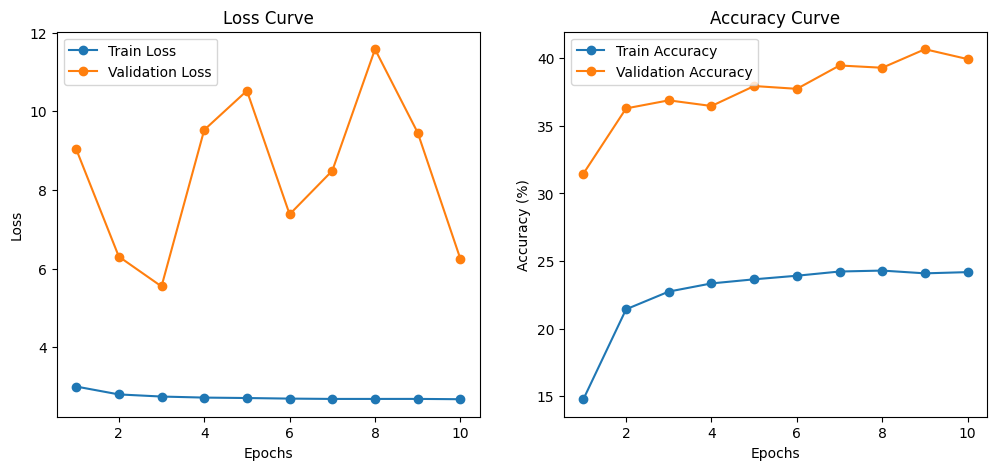

In [9]:
# Plot loss curve
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), train_losses, label="Train Loss", marker='o')
plt.plot(range(1, num_epochs+1), val_losses, label="Validation Loss", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

# Plot accuracy curve
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), train_accuracies, label="Train Accuracy", marker='o')
plt.plot(range(1, num_epochs+1), val_accuracies, label="Validation Accuracy", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Curve")
plt.legend()

plt.show()

# Part 5: Bonus - Test Time Augmentation (TTA)

**Task:**

Implement Test Time Augmentation (TTA) to improve predictions!

**Steps to implement TTA:**

1. Copy the validation function you created above

2. Inside the function, for each batch, get predictions for 3 versions of the images:
   - Predictions from the **original** images
   - Predictions from **horizontally flipped** images (to get the images, use `h_flipped = torch.flip(images, dims=[3])`)
   - Predictions from **vertically flipped** images (to get the images, use `v_flipped = torch.flip(images, dims=[2])`)

3. **Average** the 3 predictions together, then pass the average to the criterion and get the accuracy

> **Redefining the model to reset previously fine-tuned model. Will now train again as per instructions.**

In [10]:
# Write your code here
model = efficientnet_v2_s(pretrained=True)

for param in model.features.parameters():
  param.requires_grad = False


model.classifier = nn.Linear(1280, 26)
model.classifier

Linear(in_features=1280, out_features=26, bias=True)

In [11]:
# Write your code here
def validate(model, dataloader, criterion, device):
    model.eval()  # Set model to evaluation mode
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), (labels-1).to(device)
            images_orig = images
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()


            outputs = torch.softmax(outputs, dim=1)
            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

            # <------ NOW HORIZONTALLY FLIPPED ---- >>
            images = torch.flip(images_orig, dims=[3])
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()


            outputs = torch.softmax(outputs, dim=1)
            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
            # <------ NOW VERTICALLY FLIPPED ---- >>

            images = torch.flip(images_orig, dims=[2])
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            # AVGING LOSS BELOW BY DIVIDING BY 3 additionally.
    avg_loss = total_loss / len(dataloader) / 3 # averaged by dividing by additional 3, cuz 3 variations tested with TTA
    accuracy = 100 * correct / total
    return avg_loss, accuracy

> **Read comments in above cell carefully. It is the updated validation function, now with Test-Time Augmentation.** 

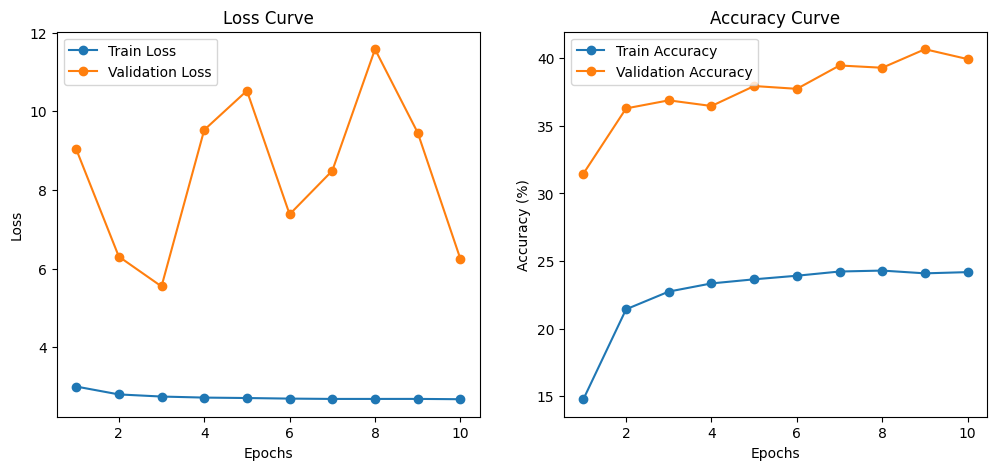

In [12]:
# Plot loss curve
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), train_losses, label="Train Loss", marker='o')
plt.plot(range(1, num_epochs+1), val_losses, label="Validation Loss", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

# Plot accuracy curve
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), train_accuracies, label="Train Accuracy", marker='o')
plt.plot(range(1, num_epochs+1), val_accuracies, label="Validation Accuracy", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Curve")
plt.legend()

plt.show()